In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

### Average filter function

In [3]:
def average_filter(image, mask_size):
    height, width = image.shape
    offset, weight = mask_size//2, mask_size*mask_size

    filteredImg = image.copy()
    for i in range(height):
        for j in range(width):
            for x in range(-offset, offset+1):
                for y in range(-offset, offset+1):
                    if (i+x >= 0 and i+x < height and j+y >= 0 and j+y < width):
                        filteredImg[i][j] += filteredImg[i+x][j+y]/weight

    return filteredImg
                    

### Adding Salt & Pepper Noise function

In [4]:
def add_salt_pepper_noise(image, noise_percent):
    height, width = image.shape
    noisedImg = image.copy()

    noise_amount = int((height*width)*(noise_percent/100))
    
    for i in range(noise_amount):
        salt_x, salt_y = np.random.randint(0,height), np.random.randint(0,width)
        pepper_x, pepper_y = np.random.randint(0,height), np.random.randint(0,width)

        noisedImg[salt_x][salt_y] = 255
        noisedImg[pepper_x][pepper_y] = 0
    return noisedImg
                    

### Function for calculating PSNR (Peak Signal to Noise Ratio)

In [5]:
def calculate_psnr(image1, image2):
    image1, image2 = np.float64(image1), np.float64(image2)
    mse = np.mean((image1 - image2)**2)
    if mse == 0:
        return 'inf'
    psnr = 20*np.log10(255.0) - 10*np.log10(mse)
    return round(psnr, 2)

### Loading original image

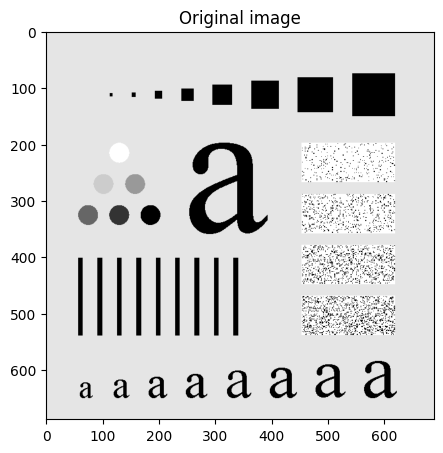

In [6]:
originalImg = cv2.imread('Characters Test Pattern 688x688.tif', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,10))
plt.title('Original image')
plt.imshow(originalImg, cmap='gray')
plt.show()


### Adding salt & pepper noise

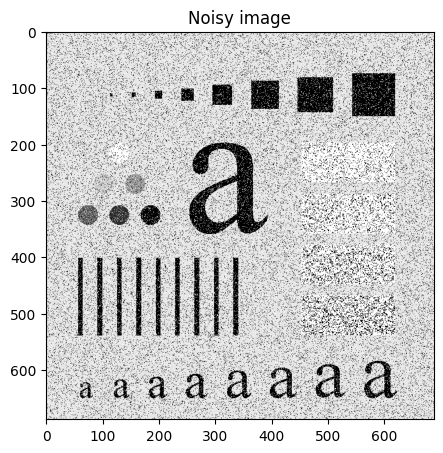

In [7]:
plt.figure(figsize=(5,10))
plt.title('Noisy image')
noise_percent = 10
noisy_image = add_salt_pepper_noise(originalImg, noise_percent)
plt.imshow(noisy_image, cmap='gray')
plt.show()


### Applying average filter with (3x3, 5x5, 7x7) mask

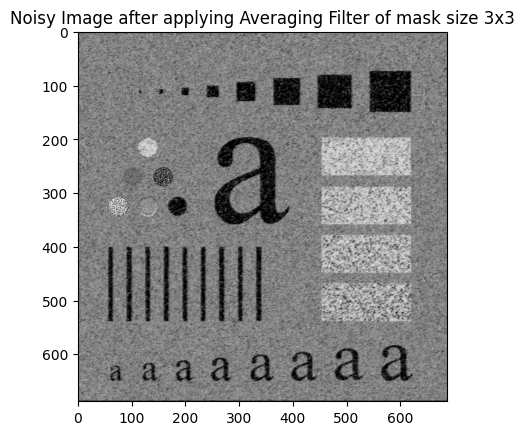

PSNR = 7.52


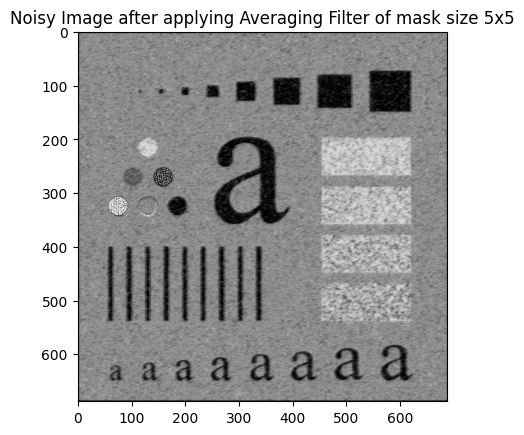

PSNR = 7.85


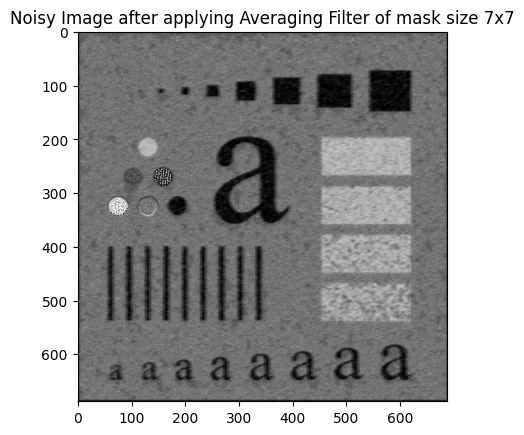

PSNR = 6.56


In [11]:
for mask_size in range(3, 8, 2):
    avg_character_image = average_filter(noisy_image, mask_size)
    plt.imshow(avg_character_image, cmap='gray')
    plt.title(f"Noisy Image after applying Averaging Filter of mask size {mask_size}x{mask_size}")
    plt.show()
    print(f"PSNR = {calculate_psnr(noisy_image, avg_character_image)}")